<a href="https://colab.research.google.com/github/yongik-jang/ml-for-very-newbies/blob/main/notebooks/02_mnist_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML for Very Newbies — Hands-On MNIST (solution)

This notebook is the hands-on part of the slides: build the model from the slides, train it,
and then break it. Sections 1–2 go with the training slides; sections 3–4 go with the CNN slides.

| notebook | slides |
|---|---|
| 1. Data | Splits, preprocessing, epoch and batch |
| 2. Fully connected network (MLP) | Forward, loss, backward, update |
| 3. The same digit, moved | Shifted digits, collapse |
| 4. CNN | Convolution, pooling, global average pooling |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
from torch.utils.data import random_split
from sklearn.metrics import confusion_matrix
from torch.utils.data import TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## 1. Data

In [2]:
# Digits are resized to 14x14, then placed on a 28x28 canvas (centered or shifted) below.
img_size = 14
transform = transforms.Compose([transforms.Resize((img_size, img_size)), transforms.ToTensor()])   # PIL image -> (1,img_size,img_size) float tensor in [0,1]

train_ds = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_ds  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]


In [3]:
train_ds, val_ds = random_split(train_ds, [55000, 5000], generator=torch.Generator().manual_seed(42))

print(f'train: {len(train_ds)} images | validation: {len(val_ds)} images | test: {len(test_ds)} images')

train: 55000 images | validation: 5000 images | test: 10000 images


In [4]:
def make_placed_dataset(dataset, canvas_size=28, mode="center", seed=0):
    X = torch.stack([dataset[i][0] for i in range(len(dataset))])
    y = torch.tensor([dataset[i][1] for i in range(len(dataset))])

    N, C, H, W = X.shape

    if H > canvas_size or W > canvas_size:
        raise ValueError(
            f"Image size ({H}, {W}) is larger than canvas size ({canvas_size}, {canvas_size})"
        )

    max_row = canvas_size - H
    max_col = canvas_size - W

    g = torch.Generator().manual_seed(seed)

    if mode == "center":
        rows = torch.full((N,), max_row // 2, dtype=torch.long)
        cols = torch.full((N,), max_col // 2, dtype=torch.long)
    elif mode == "shift":
        rows = torch.randint(0, max_row + 1, (N,), generator=g)
        cols = torch.randint(0, max_col + 1, (N,), generator=g)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    out = torch.zeros(N, C, canvas_size, canvas_size,dtype=X.dtype)

    for i in range(N):
        r = rows[i]
        c = cols[i]

        out[i, :, r:r+H, c:c+W] = X[i]

    return TensorDataset(out, y)

In [5]:
CANVAS=28

train_placed = make_placed_dataset(train_ds, canvas_size=CANVAS, mode="center")
val_placed = make_placed_dataset(val_ds, canvas_size=CANVAS, mode="center")
test_placed = make_placed_dataset(test_ds, canvas_size=CANVAS, mode="center")

train_placed_shifted = make_placed_dataset(train_ds, canvas_size=CANVAS, mode="shift")
val_placed_shifted = make_placed_dataset(val_ds, canvas_size=CANVAS, mode="shift")
test_placed_shifted = make_placed_dataset(test_ds, canvas_size=CANVAS, mode="shift")

one image shape: torch.Size([1, 28, 28])


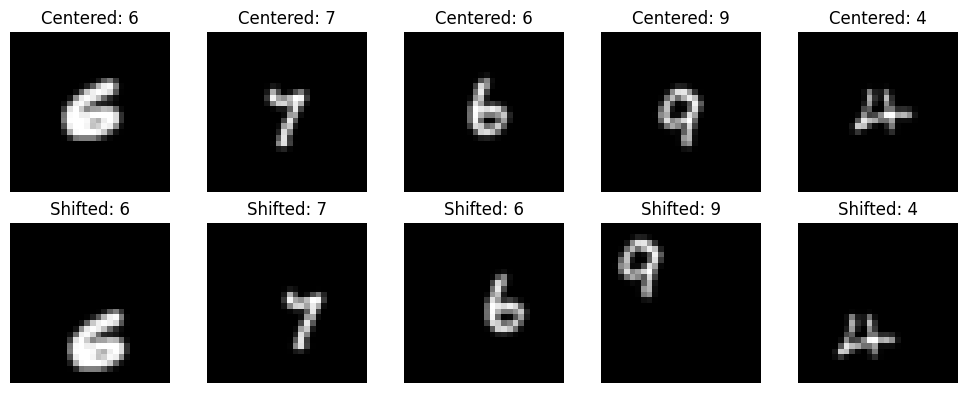

In [6]:
print('one image shape:', train_placed[0][0].shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    img, label = train_placed[i]
    axes[0, i].imshow(img.squeeze(), cmap='gray')
    axes[0, i].set_title(f"Centered: {label}")
    axes[0, i].axis('off')

    img_shift, label_shift = train_placed_shifted[i]
    axes[1, i].imshow(img_shift.squeeze(), cmap='gray')
    axes[1, i].set_title(f"Shifted: {label_shift}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
BATCH_SIZE = 256
train_loader = DataLoader(train_placed, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_placed, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_placed,  batch_size=len(test_placed), shuffle=False)

train_loader_shifted = DataLoader(train_placed_shifted, batch_size=BATCH_SIZE, shuffle=True)
val_loader_shifted   = DataLoader(val_placed_shifted, batch_size=BATCH_SIZE, shuffle=False)
test_loader_shifted  = DataLoader(test_placed_shifted,  batch_size=len(test_placed_shifted), shuffle=False)

## 2. Fully connected network (MLP)

In [8]:
from IPython.display import clear_output, display
def plot_history(history):
    clear_output(wait=True)
    fig, ax1 = plt.subplots(figsize=(8, 5))

    epochs = range(1, len(history['train_loss'])+1)

    ax1.plot(
        epochs,
        history['train_loss'],
        label='Train Loss',
        color='blue'
    )
    ax1.plot(
        epochs,
        history['val_loss'],
        label='Val Loss',
        color='skyblue'
    )

    ax1.set_xlabel('Epoch', fontsize=15)
    ax1.set_ylabel('Loss', color='blue', fontsize=15)
    ax1.tick_params(axis='y', labelcolor='blue', labelsize=15)
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()

    ax2.plot(
        epochs,
        history['train_acc'],
        label='Train Acc',
        color='red'
    )
    ax2.plot(
        epochs,
        history['val_acc'],
        label='Val Acc',
        color='orange'
    )

    ax2.set_ylabel('Accuracy', color='red', fontsize=15)
    ax2.tick_params(axis='y', labelcolor='red', labelsize=15)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc='center right',
        fontsize=15,
        frameon=False
    )

    plt.tight_layout()

    display(fig)
    plt.close(fig)

In [9]:
def train_nn(model, train_loader, val_loader, epochs, lr):
    model   = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for _ in range(1, epochs+1, 1):
        model.train()
        run_loss, n_correct, n_tot = 0., 0., 0.
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            output = model(xb)
            loss   = loss_fn(output, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            run_loss  += loss.item() * xb.size(0)
            n_correct += (output.argmax(1) == yb).sum().item()
            n_tot     += xb.size(0)

        tr_loss, tr_acc = run_loss/n_tot, n_correct/n_tot

        model.eval()
        with torch.no_grad():
            run_loss, n_correct, n_tot = 0., 0., 0.
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                output = model(xb)
                loss   = loss_fn(output, yb)
                run_loss  += loss.item() * xb.size(0)
                n_correct += (output.argmax(1) == yb).sum().item()
                n_tot     += xb.size(0)

            val_loss, val_acc = run_loss/n_tot, n_correct/n_tot

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)

        plot_history(history)

    return history

In [10]:
class FCN(nn.Module):
    def __init__(self, dims, bn=False, p=0.3):
        super().__init__()
        layers = [nn.Flatten()]
        n = len(dims) - 1
        for k in range(n):
            if k != n-1:
                linear = nn.Linear(dims[k], dims[k+1], bias=not bn)
                nn.init.kaiming_uniform_(linear.weight, nonlinearity='relu')
                layers.append(linear)
                if bn:
                    layers.append(nn.BatchNorm1d(dims[k+1]))
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(p))
            else:
                linear = nn.Linear(dims[k], dims[k+1])
                nn.init.kaiming_uniform_(linear.weight, nonlinearity='linear')
                layers.append(linear)

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [11]:
n_input = int(CANVAS*CANVAS)

net1 = FCN([n_input, 256, 128, 10], bn=True, p=0.3)
print(net1)
print(f'number of parameters: {sum(p.numel() for p in net1.parameters()):,}')

FCN(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=False)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=False)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)
number of parameters: 235,530


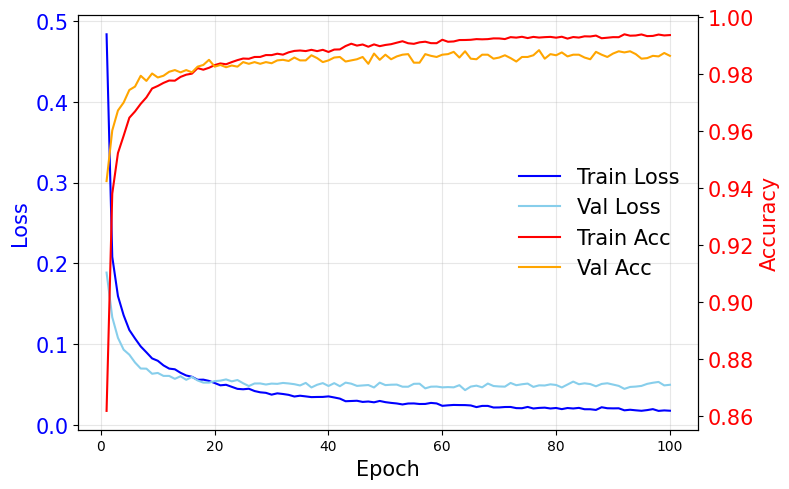

In [12]:
_ = train_nn(net1, train_loader, val_loader, epochs=100, lr=1e-3)

In [13]:
def net_test(model, test_loader):
    model.eval()

    n_correct, n_total = 0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            output = model(xb)
            pred   = output.argmax(dim=1)

            n_correct += (pred==yb).sum().item()
            n_total   += yb.size(0)

            y_true.extend(yb.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    test_acc = n_correct / n_total

    return test_acc, y_true, y_pred

Test Accuracy: 0.9851


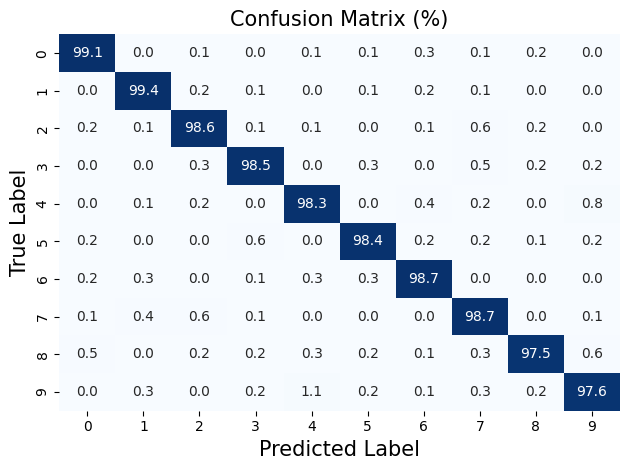

In [14]:
test_acc, y_true, y_pred = net_test(net1, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")

cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, None] * 100

sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues", xticklabels=range(10), yticklabels=range(10), cbar=False)

plt.xlabel("Predicted Label", fontsize=15)
plt.ylabel("True Label", fontsize=15)
plt.title("Confusion Matrix (%)", fontsize=15)
plt.tight_layout()
plt.show()

## 3. The same digit, moved

Same network, same digits — only the position changes.

Test Accuracy: 0.1367


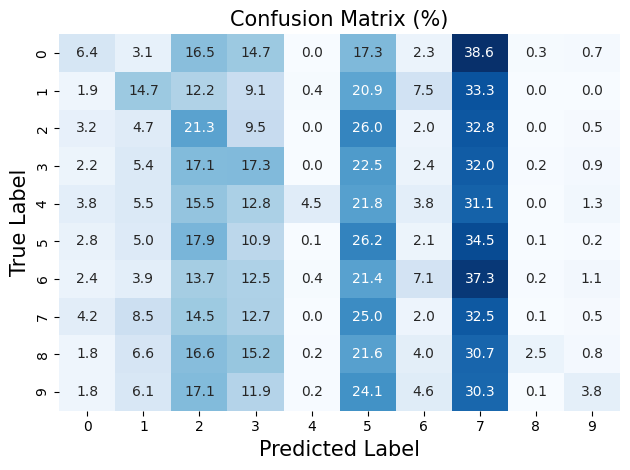

In [15]:
test_acc_shifted, y_true_shifted, y_pred_shifted = net_test(net1, test_loader_shifted)
print(f"Test Accuracy: {test_acc_shifted:.4f}")

cm = confusion_matrix(y_true_shifted, y_pred_shifted)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, None] * 100

sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues", xticklabels=range(10), yticklabels=range(10), cbar=False)

plt.xlabel("Predicted Label", fontsize=15)
plt.ylabel("True Label", fontsize=15)
plt.title("Confusion Matrix (%)", fontsize=15)
plt.tight_layout()
plt.show()

## 4. CNN
### Embedding translational symmetry

In [16]:
class CNN(nn.Module):
    def __init__(self, channels, num_classes=10, bn=False, p=0.3):
        super().__init__()
        layers = []
        # Convolutional blocks
        for k in range(len(channels) - 1):

            conv = nn.Conv2d(channels[k], channels[k + 1], kernel_size=3, padding=1, bias=not bn)
            nn.init.kaiming_uniform_(conv.weight, nonlinearity='relu')
            layers.append(conv)
            if bn:
                layers.append(nn.BatchNorm2d(channels[k + 1]))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2))
            layers.append(nn.Dropout2d(p))

        self.features = nn.Sequential(*layers)

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier
        self.classifier = nn.Linear(channels[-1], num_classes)
        nn.init.kaiming_uniform_(self.classifier.weight, nonlinearity='linear')

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [17]:
net2 = CNN(channels=[1, 16, 64], num_classes=10, bn=True, p=0.3)

print(net2)
print(f'number of parameters: {sum(p.numel() for p in net2.parameters()):,}')

CNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.3, inplace=False)
    (5): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.3, inplace=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=1)
  (classifier): Linear(in_features=64, out_features=10, bias=True)
)
number of parameters: 10,170


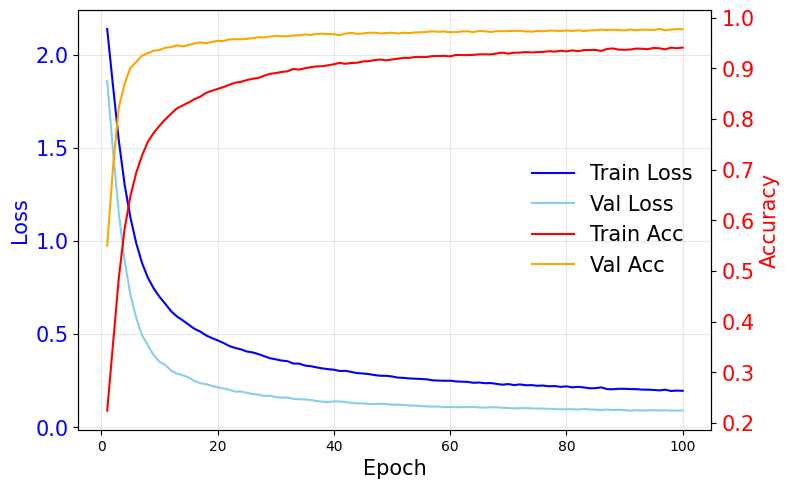

In [18]:
_ = train_nn(net2, train_loader, val_loader, epochs=100, lr=1e-3)

Test Accuracy: 0.9797


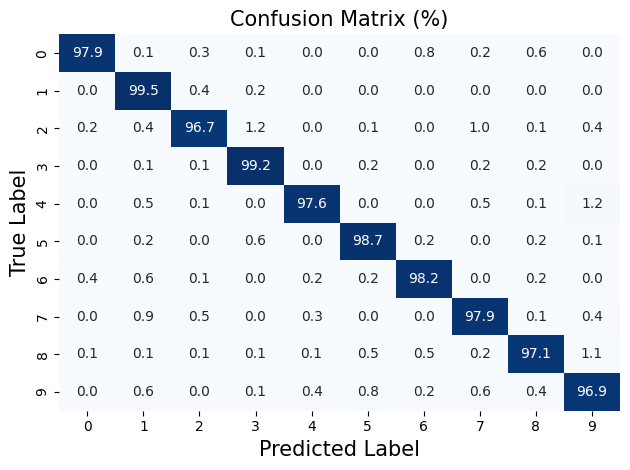

In [19]:
test_acc, y_true, y_pred = net_test(net2, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")

cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, None] * 100

sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues", xticklabels=range(10), yticklabels=range(10), cbar=False)

plt.xlabel("Predicted Label", fontsize=15)
plt.ylabel("True Label", fontsize=15)
plt.title("Confusion Matrix (%)", fontsize=15)
plt.tight_layout()
plt.show()

Test Accuracy: 0.9736


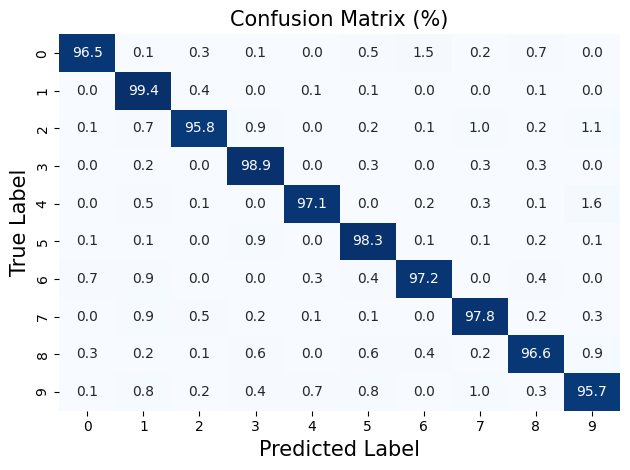

In [20]:
test_acc_shifted, y_true_shifted, y_pred_shifted = net_test(net2, test_loader_shifted)
print(f"Test Accuracy: {test_acc_shifted:.4f}")

cm = confusion_matrix(y_true_shifted, y_pred_shifted)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, None] * 100

sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues", xticklabels=range(10), yticklabels=range(10), cbar=False)

plt.xlabel("Predicted Label", fontsize=15)
plt.ylabel("True Label", fontsize=15)
plt.title("Confusion Matrix (%)", fontsize=15)
plt.tight_layout()
plt.show()